In [1]:
"""
DeepHalo + Sparse shocks simulation suite.
"""

import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.backend.set_floatx("float64")

from matplotlib import pyplot as plt

from dataclasses import dataclass
from choice_learn.data import ChoiceDataset

import pandas as pd
import os
import sys

project_root = os.path.abspath(os.getcwd())
sys.path.insert(0, project_root)

import types
import tqdm.auto as _tqdm_auto

# Bypass tqdm in LuSparseRandomLogit to avoid printing a new line for every iteration
_fake_tqdm = types.ModuleType("tqdm")
_fake_tqdm.tqdm = _tqdm_auto.tqdm
_fake_tqdm.trange = _tqdm_auto.trange
sys.modules["tqdm"] = _fake_tqdm

from BayesianSparseDeepHalo.DeepHalo import DeepHaloEncoder

from BayesianSparseDeepHalo.GenerateData import generate_teacher_dgp
from BayesianSparseDeepHalo.DeepHalo_MCEM_Core import (
    compute_probs_and_ll_batch_masked,
    build_choice_dataset_from_market_counts,
    SparseDeepHaloMCEM,
)

# restore the tqdm
from tqdm.auto import tqdm, trange


In [2]:
# ============================================================
# Dataclasses 
# ============================================================
@dataclass
class SimParams:
    """Simulation Parameters for Data Generation"""
    T: int = 100
    M: int = 15
    J: int = 12
    Nt: int = 1000
    D: int = 2
    pi: float = 0.9
    sigma_xibar: float = 0.5
    sigma_eta: float = 0.5
    seed: int = 123

@dataclass
class MCMCParams:
    """Hyperparameters for the MCMC sampler used inside MCEM"""
    R0: int = 200
    G: int = 2000
    burn: int = 500
    # Priors
    tau0: float = 1e-3
    tau1: float = 1.0
    a_phi: float = 2.0
    b_phi: float = 8.0
    V_beta: float = 10.0
    V_xibar: float = 10.0
    V_r: float = 0.5
    
    step_beta: float = 0.20
    step_r: float = 0.20
    step_xibar: float = 0.20
    step_eta: float = 0.20
    step_phi: float = 0.20
    # Random-coefficient mask (all dims random by default, set in run_one_rep)
    random_coef_mask: object = None

    target_accept: float = 0.35


@dataclass
class EMParams:
    """Hyperparameters controlling the outer MCEM loop"""
    outer_iters: int = 25
    recalibrate_each_outer: bool = False
    mcmc_per_outer: int = 2000
    burn: int = 1000
    thin: int = 1
    nn_steps: int = 150
    nn_lr: float = 1e-3
    nn_l2: float = 1e-6

In [3]:
# ============================================================
# Baseline helpers (unchanged from DeepHalo_sparse_Lu.py)
# ============================================================
def fit_baseline(X_train, q_train, avail_train, encoder_kwargs,
                 R0=200, steps=400, lr=1e-3, nn_l2=1e-6, seed=0):
    tf.random.set_seed(seed)
    X = tf.constant(X_train, tf.float64)
    q = tf.constant(q_train, tf.float64)
    avail = tf.constant(avail_train, tf.float64)
    T, M, D = X_train.shape

    enc = DeepHaloEncoder(**{**encoder_kwargs, "out_dim": D})
    enc(X[:2], avail[:2], training=False)  # build weights

    beta = tf.Variable(tf.zeros((D,), tf.float64))
    r = tf.Variable(tf.zeros((D,), tf.float64))
    v_draws = tf.random.normal((R0, D), dtype=tf.float64)
    opt = tf.keras.optimizers.Adam(lr)

    
    @tf.function
    def step():
        with tf.GradientTape() as tape:
            Z = enc(X, avail, training=True)
            xi0 = tf.zeros((T, M), tf.float64)
            _, _, ll_vec = compute_probs_and_ll_batch_masked(Z, q, avail, xi0, beta, r, v_draws)
            nll = -tf.reduce_sum(ll_vec) / (tf.reduce_sum(q) + 1e-12)
            l2 = tf.add_n([tf.reduce_sum(w**2) for w in enc.trainable_weights])
            loss = nll + tf.cast(nn_l2, tf.float64) * l2
        grads = tape.gradient(loss, enc.trainable_weights + [beta, r])
        opt.apply_gradients(zip(grads, enc.trainable_weights + [beta, r]))
        return loss

    losses = []
    for _ in tqdm(range(steps), desc="Fit baseline DeepHalo", leave=False):
        loss = step()
        losses.append(loss)
        
    return {"encoder": enc, "beta": beta.numpy(), "r": r.numpy(), "losses": losses}

def fit_xibar_only(X_train, q_train, avail_train, encoder_kwargs,
                   R0=200, steps=600, lr=1e-3, nn_l2=1e-6, xi_l2=1e-3, seed=0):
    tf.random.set_seed(seed)
    X = tf.constant(X_train, tf.float64)
    q = tf.constant(q_train, tf.float64)
    avail = tf.constant(avail_train, tf.float64)
    T, M, D = X_train.shape

    enc = DeepHaloEncoder(**{**encoder_kwargs, "out_dim": D})
    enc(X[:2], avail[:2], training=False)

    beta = tf.Variable(tf.zeros((D,), tf.float64))
    r = tf.Variable(tf.zeros((D,), tf.float64))
    xi_bar = tf.Variable(tf.zeros((T,), tf.float64))
    v_draws = tf.random.normal((R0, D), dtype=tf.float64)
    opt = tf.keras.optimizers.Adam(lr)

    
    @tf.function
    def step():
        with tf.GradientTape() as tape:
            Z = enc(X, avail, training=True)
            xi = xi_bar[:, None] + tf.zeros((T, M), tf.float64)
            _, _, ll_vec = compute_probs_and_ll_batch_masked(Z, q, avail, xi, beta, r, v_draws)
            nll = -tf.reduce_sum(ll_vec) / (tf.reduce_sum(q) + 1e-12)
            l2net = tf.add_n([tf.reduce_sum(w**2) for w in enc.trainable_weights])
            l2xi = tf.reduce_sum(xi_bar**2)
            loss = (nll
                    + tf.cast(nn_l2, tf.float64) * l2net
                    + tf.cast(xi_l2, tf.float64) * l2xi)
        grads = tape.gradient(loss, enc.trainable_weights + [beta, r, xi_bar])
        opt.apply_gradients(zip(grads, enc.trainable_weights + [beta, r, xi_bar]))
        return loss

    losses = []
    for _ in tqdm(range(steps), desc="Fit DeepHalo xibar-only", leave=False):
        loss = step()
        losses.append(loss)
        
    return {"encoder": enc, "beta": beta.numpy(), "r": r.numpy(), "xi_bar": xi_bar.numpy(), "losses": losses}


In [4]:
# ============================================================
# Prediction helpers
# ============================================================
def compute_prediction_nll(encoder, X_np, q_np, avail_np,
                           beta, r, xi_bar, eta,
                           R0=200, seed=0):
    tf.random.set_seed(seed)
    X = tf.constant(X_np, tf.float64)
    q = tf.constant(q_np, tf.float64)
    avail = tf.constant(avail_np, tf.float64)
    Z = encoder(X, avail, training=False)
    Dz = int(Z.shape[-1])

    v_draws = tf.random.normal((R0, Dz), dtype=tf.float64)
    xi = tf.constant(xi_bar, tf.float64)[:, None] + tf.constant(eta, tf.float64)

    _, _, ll_vec = compute_probs_and_ll_batch_masked(
        Z, q, avail, xi,
        tf.constant(beta, tf.float64),
        tf.constant(r, tf.float64),
        v_draws,
    )
    N_total = tf.reduce_sum(q)
    return float((-tf.reduce_sum(ll_vec) / (N_total + 1e-12)).numpy())

def infer_xi_bar_for_markets(encoder, X_np, q_np, avail_np,
                             beta, r, R0=200, iters=200, lr=0.1, seed=0):
    tf.random.set_seed(seed)
    X = tf.constant(X_np, tf.float64)
    q = tf.constant(q_np, tf.float64)
    avail = tf.constant(avail_np, tf.float64)
    Z = encoder(X, avail, training=False)
    Dz = int(Z.shape[-1])
    Tt = X_np.shape[0]
    M = X_np.shape[1]

    v_draws = tf.random.normal((R0, Dz), dtype=tf.float64)
    beta_tf = tf.constant(beta, tf.float64)
    r_tf = tf.constant(r, tf.float64)
    xi_bar = tf.Variable(tf.zeros((Tt,), tf.float64))
    opt = tf.keras.optimizers.Adam(lr)

    @tf.function
    def step():
        with tf.GradientTape() as tape:
            xi = xi_bar[:, None] + tf.zeros((Tt, M), tf.float64)
            _, _, ll_vec = compute_probs_and_ll_batch_masked(Z, q, avail, xi, beta_tf, r_tf, v_draws)
            nll = -tf.reduce_sum(ll_vec) / (tf.reduce_sum(q) + 1e-12)
        grads = tape.gradient(nll, [xi_bar])
        opt.apply_gradients(zip(grads, [xi_bar]))
        return nll

    for _ in range(iters):
        step()
    return xi_bar.numpy()



# ============================================================
# Evaluation helpers
# ============================================================
def sparsity_recovery(eta_hat, eta_star, avail, tau=0.05):
    mask = avail > 0.5
    nz_true = (np.abs(eta_star) > 1e-12) & mask
    nz_hat = (np.abs(eta_hat) > tau) & mask
    tp = int(np.sum(nz_true & nz_hat))
    fp = int(np.sum(~nz_true & nz_hat))
    fn = int(np.sum(nz_true & ~nz_hat))
    prec = tp / (tp + fp + 1e-12)
    rec = tp / (tp + fn + 1e-12)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return {"tp": tp, "fp": fp, "fn": fn,
            "precision": float(prec), "recall": float(rec), "f1": float(f1)}

def theta_distance_zip(enc_a, enc_b, X_build, A_build):
    enc_a(tf.constant(X_build, tf.float64), tf.constant(A_build, tf.float64), training=False)
    enc_b(tf.constant(X_build, tf.float64), tf.constant(A_build, tf.float64), training=False)
    wa, wb = enc_a.weights, enc_b.weights
    L = min(len(wa), len(wb))
    s = 0.0
    for a, b in zip(wa[:L], wb[:L]):
        da, db = a.numpy().ravel(), b.numpy().ravel()
        if da.shape != db.shape:
            continue
        s += np.sum((da - db) ** 2)
    return float(np.sqrt(s))


def z_distance(enc, Z_true, X_np, A_np):
    """
    Computes the RMSE between the true latent features Z and the predicted Z.
    """
    Z_pred = enc(tf.constant(X_np, tf.float64), 
                 tf.constant(A_np, tf.float64), 
                 training=False).numpy()
    
    # Calculate Mean Squared Error across all elements, then take square root
    mse = np.mean((Z_true - Z_pred) ** 2)
    return float(np.sqrt(mse))


In [5]:
# ============================================================
# Train/test split
# ============================================================
def split_train_test_markets(T, test_frac=0.25, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(T)
    rng.shuffle(idx)
    n_test = int(np.round(T * test_frac))
    test_idx = np.sort(idx[:n_test])
    train_idx = np.sort(idx[n_test:])
    return train_idx, test_idx

# ============================================================
# run_one_rep 
# ============================================================
def run_one_rep(sim: SimParams, test_frac=0.25, encoder_kwargs=None, tau_eval=0.05):
    data, true, teacher = generate_teacher_dgp(sim, encoder_kwargs=encoder_kwargs)

    X, q, avail = data["X"], data["q"], data["avail"]
    T, M, D = X.shape

    train_idx, test_idx = split_train_test_markets(T, test_frac=test_frac, seed=sim.seed + 999)
    X_tr, q_tr, A_tr = X[train_idx], q[train_idx], avail[train_idx]
    X_te, q_te, A_te = X[test_idx], q[test_idx], avail[test_idx]

    if encoder_kwargs is None:
        encoder_kwargs = dict(H=7, depth=3, embed=16, dropout=0.0, block_type="qua", out_dim=D)
        
    # Baseline DeepHalo 
    est1 = fit_baseline(X_tr, q_tr, A_tr, encoder_kwargs,
                        R0=200, steps=600, lr=1e-3, nn_l2=1e-6, seed=sim.seed + 1)
    nll1_strict = compute_prediction_nll(
        est1["encoder"], X_te, q_te, A_te, est1["beta"], est1["r"],
        xi_bar=np.zeros(len(test_idx)), eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 10)
    nll1_adapt = compute_prediction_nll(
        est1["encoder"], X_te, q_te, A_te, est1["beta"], est1["r"],
        xi_bar=infer_xi_bar_for_markets(
            est1["encoder"], X_te, q_te, A_te, est1["beta"], est1["r"],
            R0=200, iters=200, lr=0.1, seed=sim.seed + 20),
        eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 21)

    # DeepHalo + xi_bar
    est2 = fit_xibar_only(X_tr, q_tr, A_tr, encoder_kwargs,
                          R0=200, steps=600, lr=1e-3, nn_l2=1e-6,
                          xi_l2=1e-3, seed=sim.seed + 2)
    nll2_strict = compute_prediction_nll(
        est2["encoder"], X_te, q_te, A_te, est2["beta"], est2["r"],
        xi_bar=np.zeros(len(test_idx)), eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 11)

    nll2_adapt = compute_prediction_nll(
        est2["encoder"], X_te, q_te, A_te, est2["beta"], est2["r"],
        xi_bar=infer_xi_bar_for_markets(
            est2["encoder"], X_te, q_te, A_te, est2["beta"], est2["r"],
            R0=200, iters=200, lr=0.1, seed=sim.seed + 30),
        eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 31)

    # Sparse DeepHalo MCEM (uses Lu module) 
    enc3 = DeepHaloEncoder(**{**encoder_kwargs, "out_dim": D})

    enc3(tf.constant(X_tr[:2], tf.float64),
         tf.constant(A_tr[:2], tf.float64), training=False)

    # Copy weights from the baseline as the starting point
    enc3.set_weights(est2["encoder"].get_weights())

    # random_coef_mask: all D dims are random 
    random_coef_mask = np.ones(D, dtype=np.float64)

    mcmc = MCMCParams(R0=200, tau0=1e-3, tau1=float(sim.sigma_eta),
                      random_coef_mask=random_coef_mask)
    # sim_params for Lu model: T=T_train, J=M (inside alts), D=Dz
    sim_lu = SimParams(T=len(train_idx), J=M, Nt=sim.Nt, D=D,
                       pi=sim.pi, sigma_xibar=sim.sigma_xibar,
                       sigma_eta=sim.sigma_eta, seed=sim.seed)

    em = EMParams(outer_iters=20,
                  mcmc_per_outer=4000, burn=2000, thin=1,
                  nn_steps=100, nn_lr=1e-3, nn_l2=1e-6)

    exp3 = SparseDeepHaloMCEM(
        X_tr, q_tr, A_tr, enc3,
        sim_params=sim_lu, mcmc_params=mcmc,
        em_params=em,
        seed=2026 + sim.seed,
    )

    exp3.initial_mcmc_state = {
        'beta': est2["beta"],
        'r': est2["r"],
        'xi_bar': est2["xi_bar"],
        'eta': np.zeros((len(train_idx), M), dtype=np.float64),
        'gamma': np.zeros((len(train_idx), M), dtype=np.int32),
        'phi': np.full((len(train_idx),), 0.5, dtype=np.float64)
    }
    out3 = exp3.run()


    beta3, r3 = out3["beta_last"], out3["r_last"]
    xi_bar3, eta3 = out3["xi_bar_last"], out3["eta_last"]

    nll3_strict = compute_prediction_nll(
        enc3, X_te, q_te, A_te, beta3, r3,
        xi_bar=np.zeros(len(test_idx)), eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 12)
    nll3_adapt = compute_prediction_nll(
        enc3, X_te, q_te, A_te, beta3, r3,
        xi_bar=infer_xi_bar_for_markets(
            enc3, X_te, q_te, A_te, beta3, r3,
            R0=200, iters=200, lr=0.1, seed=sim.seed + 40),
        eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 41)

    rec = sparsity_recovery(eta3, true["eta_star"][train_idx], A_tr, tau=tau_eval)

    # distances to teacher 
    X_tr2, A_tr2 = X_tr[:2], A_tr[:2]
    theta_d1 = theta_distance_zip(est1["encoder"], teacher, X_tr2, A_tr2)
    theta_d2 = theta_distance_zip(est2["encoder"], teacher, X_tr2, A_tr2)
    theta_d3 = theta_distance_zip(enc3, teacher, X_tr2, A_tr2)

    Z_true_train = true["Z_teacher"][train_idx]
    
    z_d1 = z_distance(est1["encoder"], Z_true_train, X_tr, A_tr)
    z_d2 = z_distance(est2["encoder"], Z_true_train, X_tr, A_tr)
    z_d3 = z_distance(enc3, Z_true_train, X_tr, A_tr)

    beta_d1 = float(np.linalg.norm(est1["beta"] - true["beta_star"]))
    beta_d2 = float(np.linalg.norm(est2["beta"] - true["beta_star"]))
    beta_d3 = float(np.linalg.norm(beta3 - true["beta_star"]))
    r_d1 = float(np.linalg.norm(est1["r"] - true["r_star"]))
    r_d2 = float(np.linalg.norm(est2["r"] - true["r_star"]))
    r_d3 = float(np.linalg.norm(r3 - true["r_star"]))

    rep_results = {
        "seed": int(sim.seed), "T": int(sim.T), "M": int(sim.M),
        "J": int(sim.J), "D": int(sim.D), "Nt": int(sim.Nt),
        "pi": float(sim.pi),
        "sigma_xibar": float(sim.sigma_xibar), "sigma_eta": float(sim.sigma_eta),
        "nll_strict_baseline": float(nll1_strict),
        "nll_strict_xibaronly": float(nll2_strict),
        "nll_strict_sparse": float(nll3_strict),
        "nll_adapt_baseline": float(nll1_adapt),
        "nll_adapt_xibaronly": float(nll2_adapt),
        "nll_adapt_sparse": float(nll3_adapt),
        "eta_f1": float(rec["f1"]),
        "eta_precision":float(rec["precision"]),
        "eta_recall": float(rec["recall"]),
        "beta_dist_baseline": beta_d1, "r_dist_baseline": r_d1, "theta_dist_baseline": theta_d1,  "z_dist_baseline": z_d1,
        "beta_dist_xibar": beta_d2, "r_dist_xibar": r_d2, "theta_dist_xibar": theta_d2,  "z_dist_xibar": z_d2,
        "beta_dist_sparse": beta_d3, "r_dist_sparse": r_d3, "theta_dist_sparse": theta_d3,  "z_dist_sparse": z_d3,
        "step_beta": out3["step_beta"],
        "step_r": out3["step_r"],
        "step_xibar": out3["step_xibar"],
        "step_eta": out3["step_eta"],
    }
    
    loss_results =  {
        "loss_base_train": est1["losses"],
        "loss_xibaronly_train": est2["losses"],
        "loss_sparse_train": out3["outer_losses"],
        }
    return rep_results, loss_results

# ============================================================
# run_grid
# ============================================================
def run_grid(pis=(0.8, 0.9, 0.95), reps=5, base_seed=123,
             T=25, M=10, J=8, Nt=1000, D=2,
             sigma_xibar=0.5, sigma_eta=0.5,
             test_frac=0.25, encoder_kwargs=None, tau_eval=0.05):
    rows = []
    all_losses = []
    for pi in tqdm(pis, desc="pi grid"):
        for r in tqdm(range(reps), desc="rep", leave=False):
            sim = SimParams(
                T=int(T), M=int(M), J=int(J), Nt=int(Nt), D=int(D),
                pi=float(pi),
                sigma_xibar=float(sigma_xibar), sigma_eta=float(sigma_eta),
                seed=int(base_seed + r),
            )
            row, losses = run_one_rep(sim, test_frac=test_frac,
                              encoder_kwargs=encoder_kwargs, tau_eval=tau_eval)
            rows.append(row)
            all_losses.append(losses)
            
         
    return pd.DataFrame(rows), all_losses



In [6]:
df, all_losses = run_grid(
    pis=(0.8, 0.9, 0.95), reps=5, base_seed=123,
    T=15,             # More markets to stabilize Z and beta
    M=20, J=15,       # Crucial: More items so eta cannot hide in xibar
    Nt=2000,          # Standard consumer count
    D=2,
    sigma_xibar=0.1,  # Lower market noise to prevent it from masking eta
    sigma_eta=2.0,    # Huge sparse shocks
    test_frac=0.25,
    encoder_kwargs=dict(H=7, depth=3, embed=16, dropout=0.0,
                        block_type="qua", out_dim=2),
    tau_eval=0.05,
)

out_dir = os.path.join(project_root, "Experiments", "Joint Lu Zhang results" )
os.makedirs(out_dir, exist_ok=True)

out_csv = os.path.join(out_dir, "Bayesian_sparse_deephalo_results.csv")
df.to_csv(out_csv, index=False)

pi grid:   0%|          | 0/3 [00:00<?, ?it/s]

rep:   0%|          | 0/5 [00:00<?, ?it/s]

Fit baseline DeepHalo:   0%|          | 0/600 [00:00<?, ?it/s]

Fit DeepHalo xibar-only:   0%|          | 0/600 [00:00<?, ?it/s]

--- Starting Bayesian Shrinkage Random Logit ---


...

MCMC chain:   0%|          | 0/4000 [00:00<?, ?it/s]

--- Starting Bayesian Shrinkage Random Logit ---


MCMC chain:   0%|          | 0/4000 [00:00<?, ?it/s]

--- Starting Bayesian Shrinkage Random Logit ---


MCMC chain:   0%|          | 0/4000 [00:00<?, ?it/s]

In [7]:
df

,seed,T,M,J,D,Nt,pi,sigma_xibar,sigma_eta,nll_strict_baseline,...,theta_dist_xibar,z_dist_xibar,beta_dist_sparse,r_dist_sparse,theta_dist_sparse,z_dist_sparse,step_beta,step_r,step_xibar,step_eta
0,123,15,20,15,2,2000,0.80,0.1,2,3.316967,...,30.878862,4.635713,0.719152,0.787289,31.006338,3.685531,1.000000e-12,1.000000e-12,0.2,0.3
1,124,15,20,15,2,2000,0.80,0.1,2,2.830861,...,30.626790,4.576510,0.495441,0.151317,30.338740,6.487436,1.000000e-12,1.000000e-12,0.2,0.3
2,125,15,20,15,2,2000,0.80,0.1,2,2.253894,...,31.280236,10.663025,1.890358,0.833549,30.481950,10.042909,1.000000e-12,1.000000e-12,0.2,0.3
3,126,15,20,15,2,2000,0.80,0.1,2,2.855132,...,31.333113,7.303885,1.350247,0.396644,30.552697,8.810241,1.000000e-12,1.000000e-12,0.2,0.3
4,127,15,20,15,2,2000,0.80,0.1,2,3.604434,...,31.682257,5.382063,0.393855,0.347072,30.823624,5.989734,1.000000e-12,1.000000e-12,0.2,0.3
5,123,15,20,15,2,2000,0.90,0.1,2,2.341558,...,30.493467,10.165480,0.559185,0.693408,30.477187,4.579989,1.000000e-12,1.000000e-12,0.2,0.3
6,124,15,20,15,2,2000,0.90,0.1,2,2.821119,...,30.444409,6.040730,0.564914,0.170302,30.605071,9.994624,1.000000e-12,1.000000e-12,0.2,0.3
7,125,15,20,15,2,2000,0.90,0.1,2,2.709416,...,30.993268,11.463189,1.783042,0.786033,30.902552,10.412829,1.000000e-12,1.000000e-12,0.2,0.3
8,126,15,20,15,2,2000,0.90,0.1,2,2.881458,...,31.167593,5.721788,1.501694,0.360543,31.270815,5.668125,1.000000e-12,1.000000e-12,0.2,0.3
9,127,15,20,15,2,2000,0.90,0.1,2,2.398168,...,31.133800,21.060487,1.097252,0.321254,30.512936,4.660305,1.000000e-12,1.000000e-12,0.2,0.3


# Plot Test loss

In [9]:
print(df.groupby("pi")[["nll_strict_sparse", "nll_adapt_sparse", "eta_f1"]].mean())

      nll_strict_sparse  nll_adapt_sparse    eta_f1
pi                                                 
0.80           2.939800          2.931177  0.265422
0.90           2.540626          2.510498  0.232807
0.95           2.519318          2.486142  0.167720


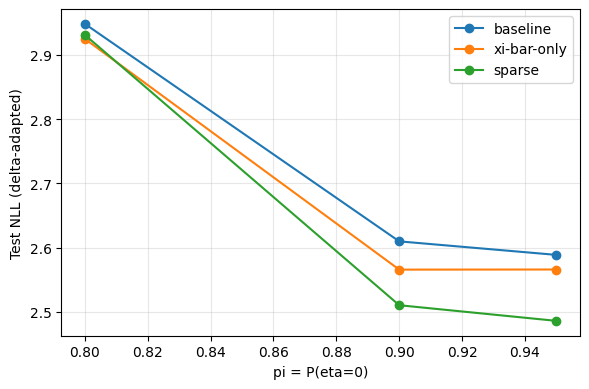

In [10]:
# plot adapted NLL vs pi
g = df.groupby("pi")[["nll_adapt_baseline", "nll_adapt_xibaronly", "nll_adapt_sparse"]].mean().reset_index()
plt.figure(figsize=(6, 4))
plt.plot(g["pi"], g["nll_adapt_baseline"], marker="o", label="baseline")
plt.plot(g["pi"], g["nll_adapt_xibaronly"], marker="o", label="xi-bar-only")
plt.plot(g["pi"], g["nll_adapt_sparse"], marker="o", label="sparse")
plt.xlabel("pi = P(eta=0)")
plt.ylabel("Test NLL (delta-adapted)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

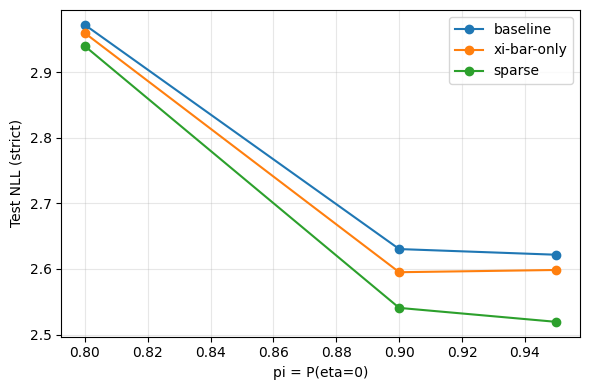

In [11]:
# plot strict  NLL vs pi
g = df.groupby("pi")[["nll_strict_baseline", "nll_strict_xibaronly", "nll_strict_sparse"]].mean().reset_index()
plt.figure(figsize=(6, 4))
plt.plot(g["pi"], g["nll_strict_baseline"], marker="o", label="baseline")
plt.plot(g["pi"], g["nll_strict_xibaronly"], marker="o", label="xi-bar-only")
plt.plot(g["pi"], g["nll_strict_sparse"], marker="o", label="sparse")
plt.xlabel("pi = P(eta=0)")
plt.ylabel("Test NLL (strict)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot traning loss

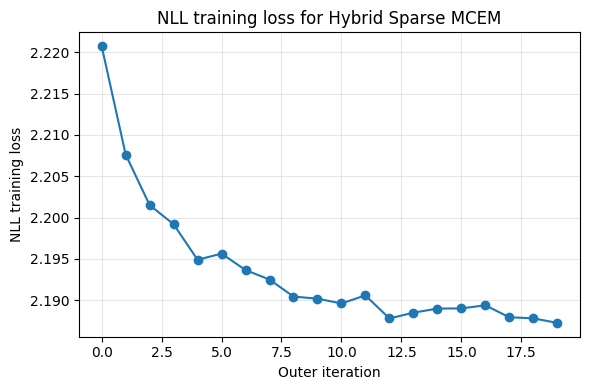

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(all_losses[0]["loss_sparse_train"], marker="o")
plt.title("NLL training loss for Hybrid Sparse MCEM")
plt.xlabel("Outer iteration")
plt.ylabel("NLL training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()